In [18]:
import pandas as pd
import json
from pathlib import Path
from elasticsearch import Elasticsearch, helpers
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

In [2]:
#Load Dyanmic Paths
BASE_DIR = Path.cwd()                        
DATA_DIR = BASE_DIR / "IR2025" or BASE_DIR / "IR2025" / "IR2025"
CSV_PATH = DATA_DIR / "documents.csv"
JSONL_PATH = DATA_DIR / "documents.jsonl"
QUERIES_PATH = DATA_DIR / "queries.csv"
QRELS_PATH = DATA_DIR / "qrels.csv"

In [3]:
# Load CSV File
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(f"File not found: {CSV_PATH}")
except Exception as e:
    raise SystemExit(f"Error reading CSV: {e}")

In [4]:
# Display Columns and Document Count
print(f"CSV loaded successfully → {len(df)} documents found")
print(f"Columns detected: {list(df.columns)}")

CSV loaded successfully → 18316 documents found
Columns detected: ['ID', 'Text']


In [5]:
# Validate Required Columns
required_cols = {"ID", "Text"}
missing = required_cols - set(df.columns)
if missing:
    raise SystemExit(f"Missing expected columns: {missing}")

In [6]:
# Convert to JSONL
records_written = 0
with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        record = {
            "id": row["ID"],     
            "text": row["Text"]
        }
        json_line = json.dumps(record, ensure_ascii=False)
        f.write(json_line + "\n")
        records_written += 1

print(f"Converted {records_written} rows → JSONL format")
print(f"Output saved at: {JSONL_PATH.resolve()}")

Converted 18316 rows → JSONL format
Output saved at: C:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\documents.jsonl


In [28]:
class Search:
    def __init__(self):
        self.es = Elasticsearch("http://127.0.0.1:9200")
        client_info = self.es.info()
        print('Connected to Elasticsearch!')
        pprint(client_info.body)

    def get_es(self):
        """Returns the Elasticsearch client instance."""
        return self.es

    def create_index(self):
        index_settings = {
            "settings": {
                "similarity": {
                    "default": {"type": "BM25"}
                },
                "analysis": {
                    "analyzer": {
                        "default": {
                            "type": "standard"
                        }
                    }
                }
            },
            "mappings": {
                "properties": {
                    "id": {"type": "keyword"},
                    "text": {"type": "text", "analyzer": "standard"}
                }
            }
        }

        self.es.indices.create(index='ir2025', body=index_settings)
        print("Index created with English analyzer and BM25 similarity.")

    def insert_document(self, document):
        """Inserts a single document."""
        return self.es.index(index='ir2025', document=document)

    def insert_documents(self, documents):
        """Inserts documents using a bulk operation."""
        operations = []
        for document in documents:
            operations.append({'index': {'_index': 'ir2025'}})
            operations.append(document)

        result = self.es.bulk(operations=operations)
        print("Insertion finished.")
        print(result)

    def delete_index(self, index_name="ir2025"):
        """Deletes the specified index."""
        if self.es.indices.exists(index=index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted successfully.")
        else:
            print(f"Index '{index_name}' does not exist.")

    def exists(self, index_name="ir2025"):
        """Checks if an index exists."""
        try:
            return self.es.indices.exists(index=index_name)
        except Exception as e:
            print(f"Error checking if index exists: {e}")
            return False

    def generate_actions(self, jsonl_path, index_name):
        """Generator for bulk indexing from a JSONL file."""
        with open(jsonl_path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield {
                    "_index": index_name,
                    "_id": i,
                    "_source": json.loads(line)
                }

    def index_documents(self, jsonl_path, index_name):
        """Uses helpers.bulk to index documents from a JSONL file."""
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.get_es(), actions)
        print(f"Successfully indexed {success} documents into '{index_name}'")

    def search_query(self, query_text, k=10, index_name="ir2025"):
        """Executes a simple match search query."""
        try:
            resp = self.es.search(
                index=index_name,
                query={"match": {"text": {"query": query_text}}},
                size=k
            )
            return resp["hits"]["hits"]
        except Exception as e:
            print(f"Error executing search query: {e}")
            return []


# ------------------------------------------------------------------
class Evaluation:
    def __init__(self, search_client):
        """Initializes with a reference to the Search instance."""
        self.search = search_client
        
    def load_file(self, filename):
        """Loads a CSV file into a pandas DataFrame (e.g., queries)."""
        df = pd.read_csv(filename, encoding="utf-8")
        print("Loaded queries successfully")
        return df

    def generate_file_results(self, dir, filename):
        """
        Loads queries, runs them against ES, and saves results in the TREC format.
        'dir' should be a pathlib.Path object.
        """
        df_queries = self.load_file(filename)
        for k in [20, 30, 50]:
            results_path = dir / f"results_{k}.txt"
            with open(results_path, "w", encoding="utf-8") as f:
                for _, row in df_queries.iterrows():
                    qid = str(row[0]) 
                    qtext = str(row[1])
                    
                    results = self.search.search_query(qtext, k) 
                    
                    for rank, hit in enumerate(results, start=1):
                        docid = hit["_source"]["id"]
                        score = hit["_score"]
                        f.write(f"{qid} Q0 {docid} {rank} {score:.4f} BM25\n")
            print(f"Created results file: {results_path}")

    def load_qrels(self, path):
        """Loads the relevance judgments (qrels) file."""
        return pd.read_csv(
            path,
            sep=";",
            header=0,
            encoding="utf-8-sig",
            names=["qid", "_", "docid", "rel"]
        )

    def load_results(self, path):
        """Loads the TREC-formatted results file."""
        return pd.read_csv(path, sep=r"\s+", header=None, names=["qid", "_", "docid", "rank", "score", "method"])

    def precision_at_k(self, results, qrels, k):
        """Calculates Precision@k."""
        precisions = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            retrieved = group.sort_values("rank").head(k)
            hits = sum(doc in rel_docs for doc in retrieved["docid"])
            precisions.append(hits / k)
        return sum(precisions) / len(precisions)

    def mean_average_precision(self, results, qrels):
        """Calculates Mean Average Precision (MAP)."""
        APs = []
        for qid, group in results.groupby("qid"):
            rel_docs = set(qrels[qrels["qid"] == qid]["docid"])
            if not rel_docs:  # Skip queries with no relevance judgments
                continue
            retrieved = group.sort_values("rank")
            hits, cum_prec = 0, 0.0
            for i, doc in enumerate(retrieved["docid"], 1):
                if doc in rel_docs:
                    hits += 1
                    cum_prec += hits / i
            if hits > 0:
                APs.append(cum_prec / hits)
        return sum(APs) / len(APs) if APs else 0.0

    def evaluate_results(self, qrels, DATA_DIR):
        """
        Loads result files, calculates metrics,
        and displays them in a formatted markdown table (no console spam).
        """
        all_results = {
            "Retrieval_k": [],
            "P@5": [], "P@10": [], "P@15": [], "P@20": [],
            "MAP": []
        }
        
        k_eval_values = [5, 10, 15, 20]

        for k_max in [20, 30, 50]:
            results_path = DATA_DIR / f"results_{k_max}.txt"
            results = self.load_results(results_path)

            all_results["Retrieval_k"].append(k_max)

            for k_eval in k_eval_values:
                p = self.precision_at_k(results, qrels, k_eval)
                all_results[f"P@{k_eval}"].append(p)

            map_val = self.mean_average_precision(results, qrels)
            all_results["MAP"].append(map_val)
            
        df_results = pd.DataFrame(all_results)

        # Pretty Markdown Output
        display(Markdown("### **IR Evaluation Results**"))
        display(Markdown(df_results.to_markdown(index=False)))

        return df_results

In [29]:
search=Search()
INDEX_NAME = "ir2025" 

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'LhE-1-1hSHGWtwOEbrNFSA',
 'name': 'PPAVLOU',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}


In [30]:
#Delete index if exists
if search.exists(INDEX_NAME):
    search.delete_index(index_name=INDEX_NAME)
    
#Create new empty index
search.create_index()

#Index docs
search.index_documents(JSONL_PATH,INDEX_NAME)

Index 'ir2025' deleted successfully.
Index created with English analyzer and BM25 similarity.
Successfully indexed 18316 documents into 'ir2025'


In [31]:
#Create evaluation class
evaluate=Evaluation(search)

#Generate results
evaluate.generate_file_results(DATA_DIR,QUERIES_PATH)

Loaded queries successfully
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_20.txt
Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_30.txt


C:\Users\perik\AppData\Local\Temp\ipykernel_12880\3764963578.py:120: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qid = str(row[0])
C:\Users\perik\AppData\Local\Temp\ipykernel_12880\3764963578.py:121: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  qtext = str(row[1])


Created results file: c:\Users\perik\Downloads\Semantic-Information-Retrieval-System-ElasticSearch-FAISS-Transformers-\IR2025\results_50.txt


In [32]:
#load qrels
qrels = evaluate.load_qrels(QRELS_PATH)

# Evaluate Results
dynamic_df=evaluate.evaluate_results(qrels=qrels,DATA_DIR=DATA_DIR)

### **IR Evaluation Results**

|   Retrieval_k |   P@5 |   P@10 |     P@15 |   P@20 |      MAP |
|--------------:|------:|-------:|---------:|-------:|---------:|
|            20 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.803863 |
|            30 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.767004 |
|            50 |  0.82 |   0.71 | 0.586667 |   0.52 | 0.703883 |

In [33]:
def visualize_metrics(df):
    """Generates beautiful comparison plots from the results DataFrame."""
    
    metrics_to_plot = ["P@5", "P@10", "P@15", "P@20", "MAP"]
    df_melted = df.melt(id_vars="Retrieval_k", value_vars=metrics_to_plot,
                         var_name="Metric", value_name="Score")

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(wspace=0.15) 

    sns.lineplot(
        data=df_melted,
        x="Retrieval_k",
        y="Score",
        hue="Metric",
        marker='o',
        dashes=False,
        palette="deep",
        ax=ax1
    )

    ax1.set_title("Metric Trends Across Maximum Retrieval Depth ($k_{max}$)", fontsize=14, weight="bold")
    ax1.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(df_melted["Score"].min() * 0.9, 1.05)
    ax1.legend(title="Metric", loc="upper right")
    ax1.grid(axis='y')

    map_data = df_melted[df_melted["Metric"] == "MAP"]
    for x, y in zip(map_data["Retrieval_k"], map_data["Score"]):
        ax1.text(x + 1, y, f'{y:.4f}', color='red', ha='left', va='center', fontsize=10)


    map_only_data = df_melted[df_melted["Metric"] == "MAP"]

    sns.barplot(
        data=map_only_data,
        x="Retrieval_k",
        y="Score",
        palette=sns.color_palette("Reds_d", n_colors=len(map_only_data)),
        ax=ax2
    )

    ax2.set_title("Mean Average Precision (MAP) by $k_{max}$", fontsize=14, weight="bold")
    ax2.set_xlabel("Maximum Retrieval Depth ($k_{max}$)", fontsize=12)
    ax2.set_ylabel("", fontsize=12)
    ax2.set_ylim(df_melted["Score"].min() * 0.9, 1.05) 

    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.4f", label_type="center", fontsize=12, color='white', weight='bold')

    plt.tight_layout()
    plt.show()

C:\Users\perik\AppData\Local\Temp\ipykernel_12880\1399095323.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


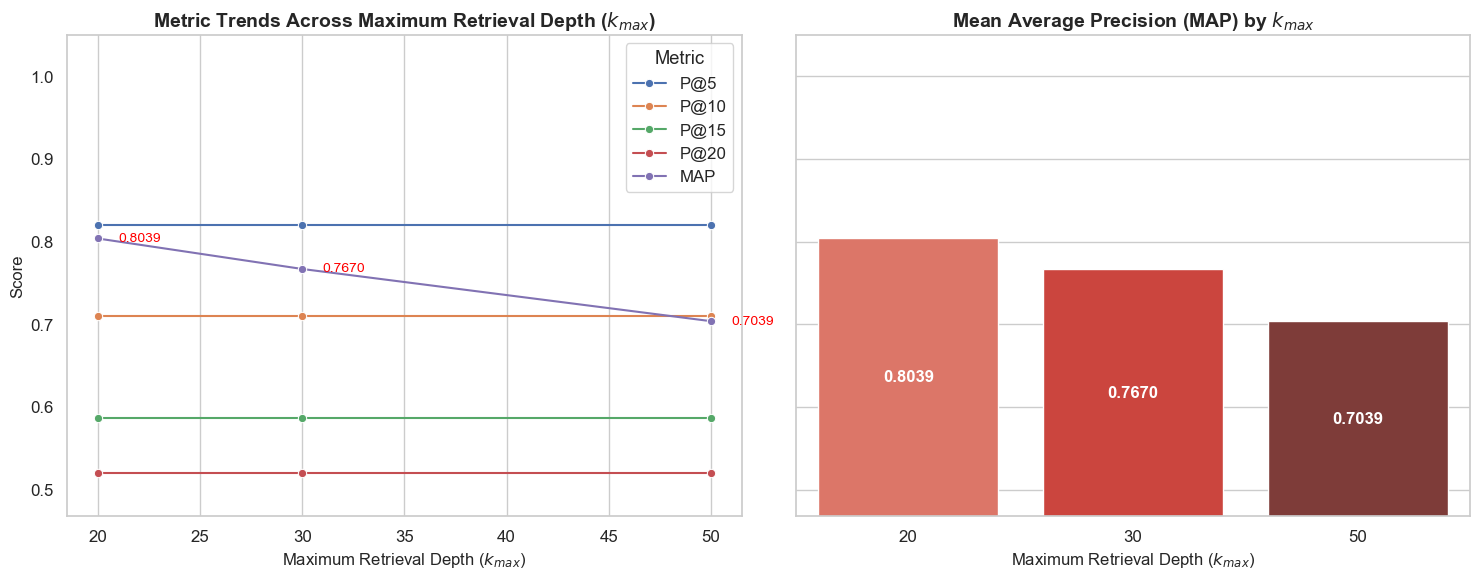

In [34]:
visualize_metrics(dynamic_df)